# Notebook 1: Architecture Probing — Migas 1.5 Internals

Reverse-engineer the Migas 1.5 model by extracting and visualizing every intermediate representation.

**Experiments:**
- **1A** — Factual vs. Predictive Signal Isolation (which section drives forecast shifts?)
- **1B** — Convex Weight Extraction (how much does the model trust Chronos vs. text?)
- **1C** — Gate & Attention Inspection (where does text enter and how strongly?)
- **1D** — Text Embedding Similarity Analysis (what does FinBERT actually differentiate?)
- **1E** — Ablation: Zero/Random/Swapped Embeddings (maximum possible text effect)

**Key question from original experiment:** Why did bullish ≈ bearish, while neutral diverged strongly?  
**Hypothesis:** The neutral summary used a *different* factual section than bullish/bearish. The factual embedding- drove the divergence.

In [1]:
import sys, os
sys.path.insert(0, "synthefy-migas/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from migaseval import MigasPipeline
from migaseval.model.util import encode_texts
from experiment_utils import (
    MigasInternalsExtractor,
    extract_text_embeddings,
    text_shift,
    cosine_sim,
    cosine_sim_matrix,
    decompose_forecast,
    plot_convex_weights,
    plot_forecast_comparison,
    plot_similarity_matrix,
    plot_gate_values,
    plot_attention_weights,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

In [20]:
# Load Migas-1.5 pipeline (includes Chronos-2 and FinBERT)
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device="cpu")
extractor = MigasInternalsExtractor(pipeline)

# Load the same cement SKU used in the original experiment
df = pd.read_csv("data/master_12Mar26_top20_skus_apr2025_onwards_weekly.csv")
df["date"] = pd.to_datetime(df["date"])

stats = (
    df.groupby(["sku", "SKU Name", "Unit"])["qty"]
    .agg(["mean", "std"])
    .assign(cv=lambda x: x["std"] / x["mean"])
    .sort_values("cv", ascending=False)
)
CHOSEN_SKU = stats.index[0][0]
CHOSEN_NAME = stats.index[0][1]
CHOSEN_UNIT = stats.index[0][2]

sku_df = df[df["sku"] == CHOSEN_SKU].sort_values("date").reset_index(drop=True)

PRED_LEN = 8
migas_df = sku_df[["date", "qty"]].rename(columns={"date": "t", "qty": "y_t"})
migas_df["t"] = migas_df["t"].dt.strftime("%Y-%m-%d")
ctx_df = migas_df.iloc[:-PRED_LEN].reset_index(drop=True)
gt = migas_df.iloc[-PRED_LEN:]["y_t"].values
context_values = ctx_df["y_t"].values.astype(np.float32)

print(f"SKU: {CHOSEN_SKU}")
print(f"Context: {len(ctx_df)} steps, Forecast: {PRED_LEN} steps")
print(f"Context mean: {context_values.mean():,.0f}, std: {context_values.std():,.0f}")

Initialized univariate model: chronos
SKU: AP1UT7T1081000UEND
Context: 41 steps, Forecast: 8 steps
Context mean: 481,963, std: 247,579


## Experiment 1A — Factual vs. Predictive Signal Isolation

The original experiment had a **confound**: bullish and bearish shared a rich, data-specific factual section, while neutral had a vague generic factual section. We isolate the two sections by crossing:

| | Rich Factual | Generic Factual |
|---|---|---|
| **Bullish Predictive** | ✓ (original) | ✓ (new) |
| **Bearish Predictive** | ✓ (original) | ✓ (new) |
| **Neutral Predictive** | ✓ (new) | ✓ (original) |

If the **factual section** drives the divergence, then all "Rich Factual" rows should cluster together regardless of predictive signals, and all "Generic Factual" rows should cluster separately.

In [21]:
# Build the two factual sections
rich_factual = (
    "FACTUAL SUMMARY:\n"
    f"Weekly cement dispatch for {CHOSEN_SKU} ranged from "
    f"{ctx_df['y_t'].min():.0f} to {ctx_df['y_t'].max():.0f} units over "
    f"{len(ctx_df)} weeks ({ctx_df['t'].iloc[0]} to {ctx_df['t'].iloc[-1]}). "
    f"Mean dispatch was {ctx_df['y_t'].mean():.0f} with std {ctx_df['y_t'].std():.0f}. "
    f"Recent 4-week average: {ctx_df['y_t'].iloc[-4:].mean():.0f}."
)

generic_factual = (
    "FACTUAL SUMMARY:\n"
    "The series shows typical weekly fluctuations in dispatch volumes."
)

# Three predictive signal variants
bullish_pred = (
    "\n\nPREDICTIVE SIGNALS:\n"
    "Strong construction demand surge expected. Infrastructure spending accelerating, "
    "monsoon season ending boosts activity. Dispatch volumes likely to increase significantly "
    "with substantial upward fluctuations well above recent averages. "
    "Project a sharp 30-50% increase from current levels."
)

bearish_pred = (
    "\n\nPREDICTIVE SIGNALS:\n"
    "Demand destruction ahead. Monsoon intensification, labor shortages, and input cost "
    "inflation expected to depress dispatch volumes significantly. Likely sharp decline "
    "of 30-50% from recent levels with continued downward pressure."
)

neutral_pred = (
    "\n\nPREDICTIVE SIGNALS:\n"
    "No strong directional signals. Expect continuation of recent patterns."
)

# Build the 6 crossed scenarios
scenarios_1a = {
    "Rich+Bullish":   rich_factual + bullish_pred,
    "Rich+Bearish":   rich_factual + bearish_pred,
    "Rich+Neutral":   rich_factual + neutral_pred,
    "Generic+Bullish": generic_factual + bullish_pred,
    "Generic+Bearish": generic_factual + bearish_pred,
    "Generic+Neutral": generic_factual + neutral_pred,
}

# Show what the model sees for one example
print("=== Rich+Bullish ===")
print(scenarios_1a["Rich+Bullish"])
print()
print("=== Generic+Neutral ===")
print(scenarios_1a["Generic+Neutral"])

=== Rich+Bullish ===
FACTUAL SUMMARY:
Weekly cement dispatch for AP1UT7T1081000UEND ranged from 123516 to 863822 units over 41 weeks (2025-04-09 to 2026-01-14). Mean dispatch was 481963 with std 250654. Recent 4-week average: 681794.

PREDICTIVE SIGNALS:
Strong construction demand surge expected. Infrastructure spending accelerating, monsoon season ending boosts activity. Dispatch volumes likely to increase significantly with substantial upward fluctuations well above recent averages. Project a sharp 30-50% increase from current levels.

=== Generic+Neutral ===
FACTUAL SUMMARY:
The series shows typical weekly fluctuations in dispatch volumes.

PREDICTIVE SIGNALS:
No strong directional signals. Expect continuation of recent patterns.


In [4]:
# Run all 6 scenarios through the extractor
results_1a = extractor.run_batch(context_values, scenarios_1a, pred_len=PRED_LEN)

# Collect forecasts and Chronos baseline
forecasts_1a = {name: r["forecast"] for name, r in results_1a.items()}
chronos_fc = results_1a["Rich+Bullish"]["chronos_forecast"]  # same for all (same context)
forecasts_1a["Chronos-2 (baseline)"] = chronos_fc

print(f"{'Scenario':<22} {'Forecast[0:4]':>40}  {'TextShift':>10}")
print("-" * 75)
for name, fc in forecasts_1a.items():
    shift = text_shift(fc, chronos_fc) if name != "Chronos-2 (baseline)" else 0
    print(f"{name:<22} {str(np.round(fc[:4], 0)):>40}  {shift:>10,.0f}")

Scenario                                          Forecast[0:4]   TextShift
---------------------------------------------------------------------------
Rich+Bullish                  [578449. 564201. 542980. 504654.]      55,123
Rich+Bearish                  [578399. 563924. 544403. 505518.]      56,697
Rich+Neutral                  [580377. 567122. 554405. 515076.]      82,542
Generic+Bullish               [490213. 575189. 615896. 565165.]     166,544
Generic+Bearish               [479413. 565401. 604158. 556193.]     157,694
Generic+Neutral               [456954. 576128. 631893. 574862.]     185,285
Chronos-2 (baseline)          [572526. 553351. 521419. 478030.]           0


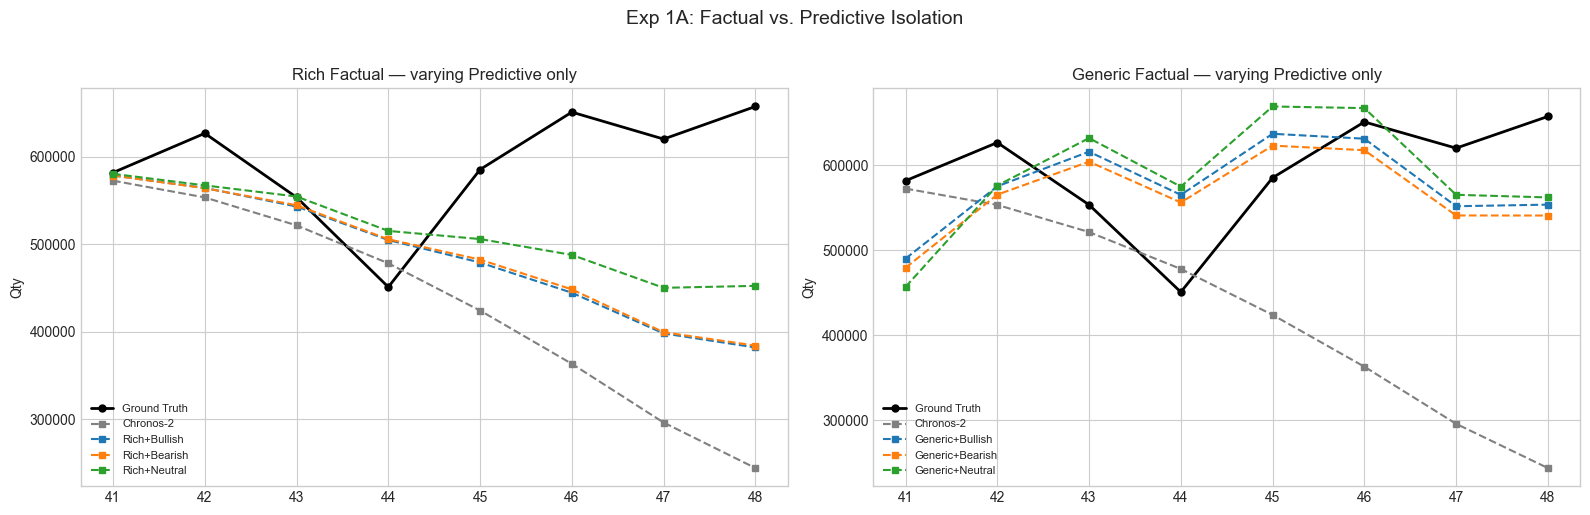

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left panel: Rich factual scenarios
ax = axes[0]
t_fc = range(len(context_values), len(context_values) + PRED_LEN)
ax.plot(t_fc, gt, "o-", color="black", ms=5, lw=2, label="Ground Truth")
ax.plot(t_fc, chronos_fc, "s--", color="gray", ms=4, label="Chronos-2")
for name in ["Rich+Bullish", "Rich+Bearish", "Rich+Neutral"]:
    ax.plot(t_fc, forecasts_1a[name], "s--", ms=4, label=name)
ax.legend(fontsize=8)
ax.set_title("Rich Factual — varying Predictive only")
ax.set_ylabel("Qty")

# Right panel: Generic factual scenarios
ax = axes[1]
ax.plot(t_fc, gt, "o-", color="black", ms=5, lw=2, label="Ground Truth")
ax.plot(t_fc, chronos_fc, "s--", color="gray", ms=4, label="Chronos-2")
for name in ["Generic+Bullish", "Generic+Bearish", "Generic+Neutral"]:
    ax.plot(t_fc, forecasts_1a[name], "s--", ms=4, label=name)
ax.legend(fontsize=8)
ax.set_title("Generic Factual — varying Predictive only")
ax.set_ylabel("Qty")

plt.suptitle("Exp 1A: Factual vs. Predictive Isolation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Quantify: how much does changing factual vs. predictive matter?
print("=== Effect of changing PREDICTIVE (same factual) ===")
for factual_type in ["Rich", "Generic"]:
    fc_bull = forecasts_1a[f"{factual_type}+Bullish"]
    fc_bear = forecasts_1a[f"{factual_type}+Bearish"]
    fc_neut = forecasts_1a[f"{factual_type}+Neutral"]
    spread = np.mean(np.abs(fc_bull - fc_bear))
    print(f"  {factual_type} factual: Bull-Bear MAE = {spread:,.0f}, "
          f"Bull-Neutral MAE = {np.mean(np.abs(fc_bull - fc_neut)):,.0f}")

print()
print("=== Effect of changing FACTUAL (same predictive) ===")
for pred_type in ["Bullish", "Bearish", "Neutral"]:
    fc_rich = forecasts_1a[f"Rich+{pred_type}"]
    fc_generic = forecasts_1a[f"Generic+{pred_type}"]
    spread = np.mean(np.abs(fc_rich - fc_generic))
    print(f"  {pred_type} predictive: Rich-Generic MAE = {spread:,.0f}")

print()
print("=== Conclusion ===")
# Compute average effect
pred_effect = np.mean([
    np.mean(np.abs(forecasts_1a["Rich+Bullish"] - forecasts_1a["Rich+Bearish"])),
    np.mean(np.abs(forecasts_1a["Generic+Bullish"] - forecasts_1a["Generic+Bearish"])),
])
fact_effect = np.mean([
    np.mean(np.abs(forecasts_1a["Rich+Bullish"] - forecasts_1a["Generic+Bullish"])),
    np.mean(np.abs(forecasts_1a["Rich+Bearish"] - forecasts_1a["Generic+Bearish"])),
    np.mean(np.abs(forecasts_1a["Rich+Neutral"] - forecasts_1a["Generic+Neutral"])),
])
print(f"Average PREDICTIVE effect (same factual): {pred_effect:,.0f}")
print(f"Average FACTUAL effect (same predictive): {fact_effect:,.0f}")
ratio = fact_effect / (pred_effect + 1e-8)
print(f"Factual/Predictive influence ratio: {ratio:.1f}x")

=== Effect of changing PREDICTIVE (same factual) ===
  Rich factual: Bull-Bear MAE = 1,656, Bull-Neutral MAE = 27,420
  Generic factual: Bull-Bear MAE = 11,550, Bull-Neutral MAE = 18,742

=== Effect of changing FACTUAL (same predictive) ===
  Bullish predictive: Rich-Generic MAE = 112,902
  Bearish predictive: Rich-Generic MAE = 102,465
  Neutral predictive: Rich-Generic MAE = 104,706

=== Conclusion ===
Average PREDICTIVE effect (same factual): 6,603
Average FACTUAL effect (same predictive): 106,691
Factual/Predictive influence ratio: 16.2x


## Experiment 1B — Convex Weight Extraction

The final Migas forecast is a **convex combination** at each timestep:

$$\text{forecast}[t] = w[t] \cdot \text{Chronos}[t] + (1 - w[t]) \cdot \text{FusionHead}[t]$$

where $w \in [0, 1]^{\text{pred\_len}}$ is produced by a learned `convex_weight_net(fused_embedding)` with Sigmoid activation.

- **w ≈ 1.0**: Model trusts Chronos, ignores text
- **w ≈ 0.0**: Model trusts the fusion head (text-conditioned)
- **w ≈ 0.5**: Equal blend

We extract $w$ for all 6 scenarios and compare.

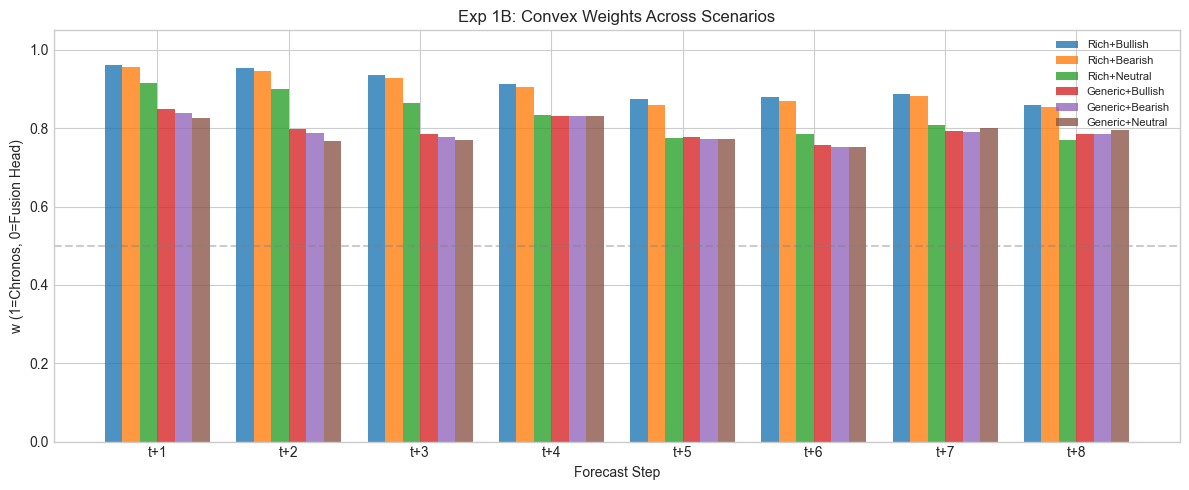

Scenario                 Mean w    Min w    Max w    Std w
-------------------------------------------------------
Rich+Bullish             0.9082   0.8599   0.9623   0.0362
Rich+Bearish             0.9000   0.8545   0.9565   0.0372
Rich+Neutral             0.8321   0.7712   0.9154   0.0528
Generic+Bullish          0.7975   0.7576   0.8489   0.0275
Generic+Bearish          0.7924   0.7524   0.8400   0.0272
Generic+Neutral          0.7900   0.7515   0.8325   0.0274


In [7]:
# Extract convex weights for all scenarios
weights_1b = {name: r["convex_weights"] for name, r in results_1a.items()}

fig, ax = plot_convex_weights(weights_1b, title="Exp 1B: Convex Weights Across Scenarios")
plt.show()

# Summary table
print(f"{'Scenario':<22} {'Mean w':>8} {'Min w':>8} {'Max w':>8} {'Std w':>8}")
print("-" * 55)
for name, w in weights_1b.items():
    print(f"{name:<22} {w.mean():>8.4f} {w.min():>8.4f} {w.max():>8.4f} {w.std():>8.4f}")

In [8]:
# Full decomposition for one scenario to show how the blend works
print("=== Forecast Decomposition: Rich+Bullish ===\n")
decomp_df = decompose_forecast(results_1a["Rich+Bullish"], pred_len=PRED_LEN)
print(decomp_df.to_string(index=False, float_format="%.2f"))

print(f"\nMax reconstruction error: {np.max(np.abs(decomp_df['Final forecast'] - decomp_df['Reconstructed'])):.4f}")
print("(Should be < 1.0 — confirms our decomposition is correct)")

=== Forecast Decomposition: Rich+Bullish ===

step  w (Chronos weight)  1-w (Fusion weight)  Chronos (norm)  Fusion head (norm)  Blended (norm)  Final forecast  Reconstructed
 t+1                0.96                 0.04            0.37                1.00            0.39       578448.88      578448.88
 t+2                0.95                 0.05            0.29                1.22            0.33       564201.06      564201.06
 t+3                0.94                 0.06            0.16                1.51            0.25       542980.50      542980.50
 t+4                0.91                 0.09           -0.02                1.23            0.09       504654.16      504654.16
 t+5                0.87                 0.13           -0.23                1.53           -0.01       478924.78      478924.78
 t+6                0.88                 0.12           -0.48                2.25           -0.15       444381.41      444381.41
 t+7                0.89                 0.11      

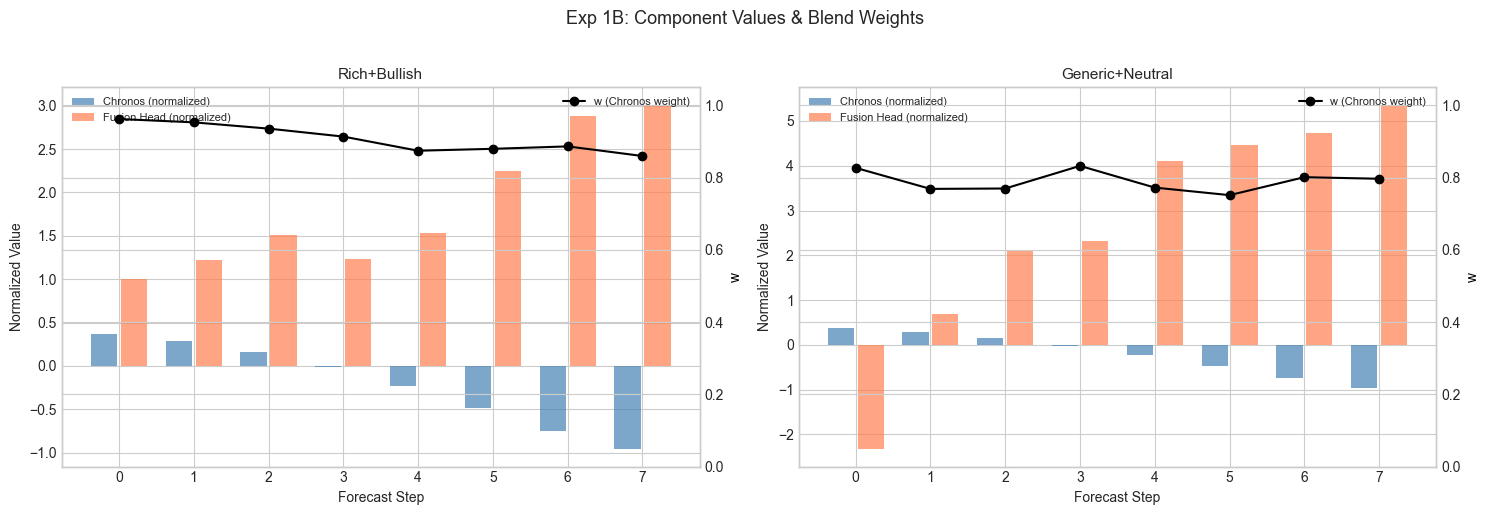

In [9]:
# Compare Chronos vs FusionHead components for two contrasting scenarios
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
steps = np.arange(PRED_LEN)

for idx, scenario in enumerate(["Rich+Bullish", "Generic+Neutral"]):
    r = results_1a[scenario]
    w = r["convex_weights"][:PRED_LEN]
    chronos_norm = r["chronos_forecast_normalized"][:PRED_LEN]
    fusion_norm = r["forecast_head_output"][:PRED_LEN]

    ax = axes[idx]
    ax.bar(steps - 0.2, chronos_norm, 0.35, label="Chronos (normalized)", color="steelblue", alpha=0.7)
    ax.bar(steps + 0.2, fusion_norm, 0.35, label="Fusion Head (normalized)", color="coral", alpha=0.7)
    ax2 = ax.twinx()
    ax2.plot(steps, w, "ko-", ms=6, label="w (Chronos weight)")
    ax2.set_ylabel("w", color="black")
    ax2.set_ylim(0, 1.05)
    ax.set_title(f"{scenario}", fontsize=11)
    ax.set_xlabel("Forecast Step")
    ax.set_ylabel("Normalized Value")
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

plt.suptitle("Exp 1B: Component Values & Blend Weights", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Experiment 1C — Gate & Attention Inspection

Inside `GatedAttentionFusion`, two things happen:

1. **Cross-attention**: The time-series embedding (query) attends over two text tokens [factual, predictive]. The attention weights tell us which text section the model focuses on.

2. **Learned gate**: A 512-dimensional sigmoid gate controls how much of the attention output is added to the time-series embedding: `output = h_ts + gate * attn_out`. Gate ≈ 0 means text is suppressed; gate ≈ 1 means text fully flows through.

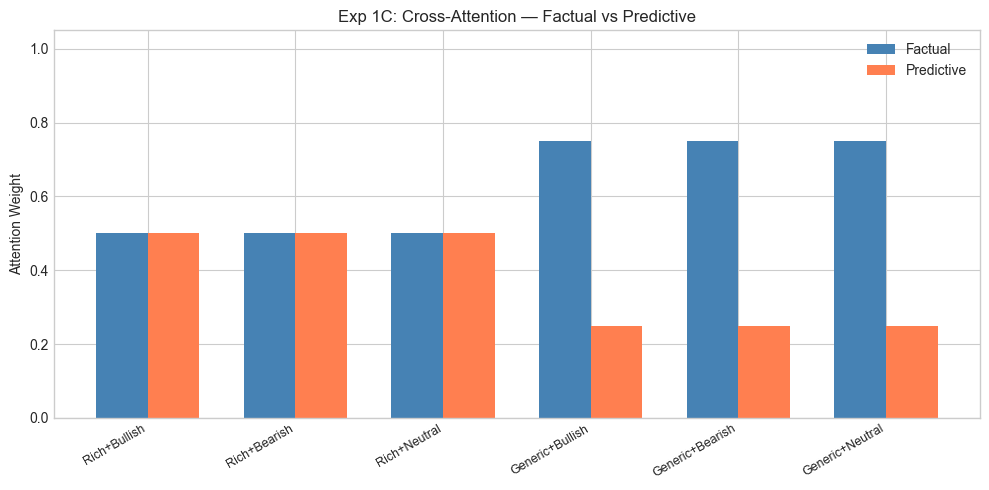

Scenario                 Attn→Factual  Attn→Predictive
-------------------------------------------------------
Rich+Bullish                   0.5000           0.5000
Rich+Bearish                   0.5000           0.5000
Rich+Neutral                   0.5000           0.5000
Generic+Bullish                0.7500           0.2500
Generic+Bearish                0.7500           0.2500
Generic+Neutral                0.7500           0.2500


In [10]:
# Extract attention weights: how much does the TS query attend to factual vs predictive?
attn_dict = {}
for name, r in results_1a.items():
    if r.get("cross_attn_weights") is not None:
        attn_dict[name] = r["cross_attn_weights"]

if attn_dict:
    fig, ax = plot_attention_weights(attn_dict, title="Exp 1C: Cross-Attention — Factual vs Predictive")
    plt.show()

    print(f"{'Scenario':<22} {'Attn→Factual':>14} {'Attn→Predictive':>16}")
    print("-" * 55)
    for name, attn in attn_dict.items():
        print(f"{name:<22} {attn[0, 0]:>14.4f} {attn[0, 1]:>16.4f}")
else:
    print("Attention weights not available (PyTorch version may suppress them)")

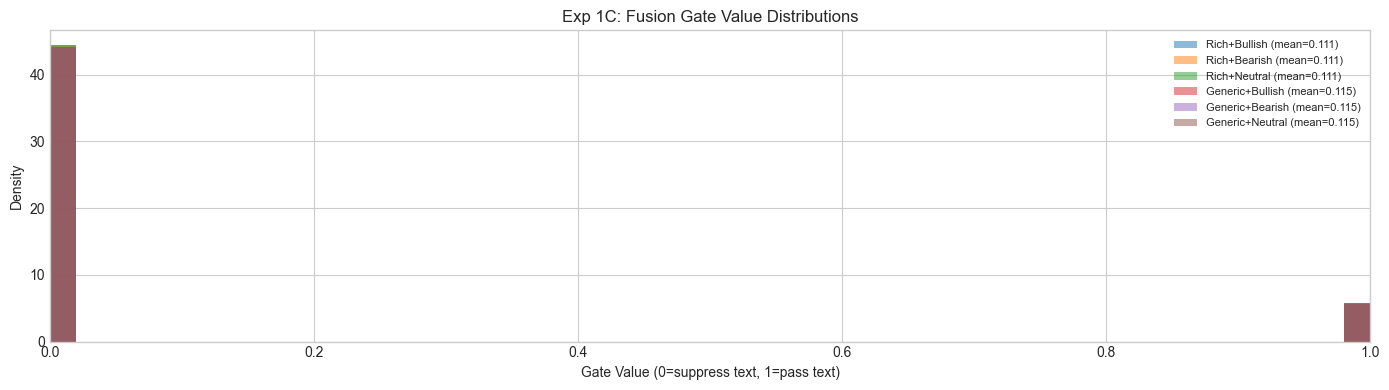

Scenario                Gate Mean   Gate Std   Gate Min   Gate Max    % > 0.5
---------------------------------------------------------------------------
Rich+Bullish               0.1113     0.3145     0.0000     1.0000      11.1%
Rich+Bearish               0.1113     0.3145     0.0000     1.0000      11.1%
Rich+Neutral               0.1113     0.3145     0.0000     1.0000      11.1%
Generic+Bullish            0.1152     0.3193     0.0000     1.0000      11.5%
Generic+Bearish            0.1152     0.3193     0.0000     1.0000      11.5%
Generic+Neutral            0.1152     0.3193     0.0000     1.0000      11.5%


In [11]:
# Extract and compare gate values across scenarios
gate_dict = {name: r["gate_values"] for name, r in results_1a.items()}

fig, ax = plot_gate_values(gate_dict, title="Exp 1C: Fusion Gate Value Distributions")
plt.show()

# Summary statistics
print(f"{'Scenario':<22} {'Gate Mean':>10} {'Gate Std':>10} {'Gate Min':>10} {'Gate Max':>10} {'% > 0.5':>10}")
print("-" * 75)
for name, gate in gate_dict.items():
    pct_above = 100 * np.mean(gate > 0.5)
    print(f"{name:<22} {gate.mean():>10.4f} {gate.std():>10.4f} {gate.min():>10.4f} {gate.max():>10.4f} {pct_above:>9.1f}%")

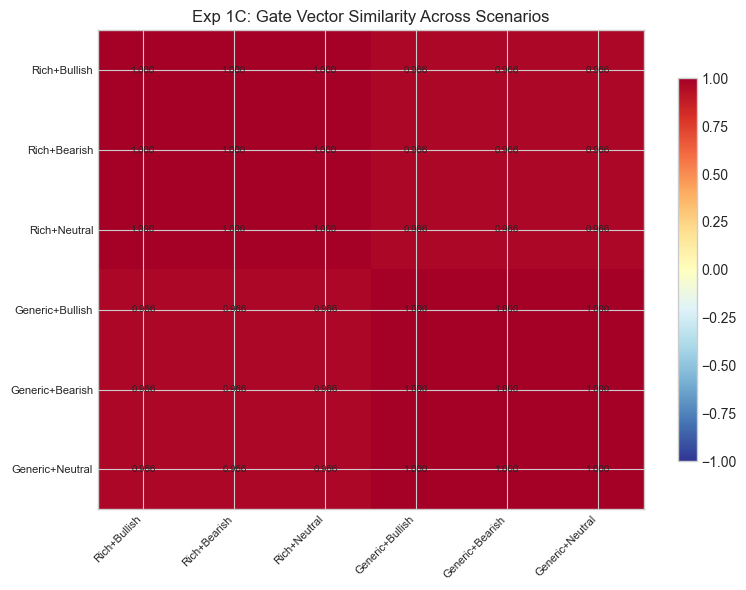


Key observations:
  Rich+Bullish vs Rich+Bearish gate sim:    1.0000
  Rich+Bullish vs Generic+Bullish gate sim: 0.9657
  Rich+Neutral vs Generic+Neutral gate sim: 0.9657


In [12]:
# Are gate patterns similar across scenarios? (cosine similarity of 512-d gate vectors)
gate_sims = cosine_sim_matrix(gate_dict)
fig, ax = plot_similarity_matrix(gate_sims, title="Exp 1C: Gate Vector Similarity Across Scenarios")
plt.show()

print("\nKey observations:")
print(f"  Rich+Bullish vs Rich+Bearish gate sim:    {gate_sims.loc['Rich+Bullish', 'Rich+Bearish']:.4f}")
print(f"  Rich+Bullish vs Generic+Bullish gate sim: {gate_sims.loc['Rich+Bullish', 'Generic+Bullish']:.4f}")
print(f"  Rich+Neutral vs Generic+Neutral gate sim: {gate_sims.loc['Rich+Neutral', 'Generic+Neutral']:.4f}")

## Experiment 1D — Text Embedding Similarity Analysis

Migas uses **FinBERT** (ProsusAI/finbert) to embed text. FinBERT was trained on financial sentiment tasks, so:
- It may differentiate bullish vs. bearish financial language well
- It may NOT differentiate domain-specific factual content (cement dispatch stats)
- The `_split_summaries()` method splits on "FACTUAL SUMMARY:" and "PREDICTIVE SIGNALS:" markers, embedding each section separately

We analyze FinBERT's raw embeddings for various text inputs to understand what it can and cannot distinguish.

In [13]:
# Build a diverse set of text inputs for embedding analysis
text_samples = {
    # === Factual sections (as parsed by _split_summaries) ===
    "Fact: Rich (data)": (
        f"Weekly cement dispatch for {CHOSEN_NAME} ({CHOSEN_UNIT}) ranged from "
        f"{ctx_df['y_t'].min():.0f} to {ctx_df['y_t'].max():.0f} units over "
        f"{len(ctx_df)} weeks. Mean dispatch was {ctx_df['y_t'].mean():.0f} "
        f"with std {ctx_df['y_t'].std():.0f}."
    ),
    "Fact: Generic": "The series shows typical weekly fluctuations in dispatch volumes.",
    "Fact: Financial": (
        "Gold prices traded between $1,800 and $2,050 per ounce over the past 12 months, "
        "with a clear uptrend driven by safe-haven demand and central bank buying."
    ),
    "Fact: Empty": "",

    # === Predictive sections ===
    "Pred: Bullish": (
        "Strong construction demand surge expected. Infrastructure spending accelerating. "
        "Project a sharp 30-50% increase from current levels."
    ),
    "Pred: Bearish": (
        "Demand destruction ahead. Significant decline of 30-50% from recent levels "
        "with continued downward pressure."
    ),
    "Pred: Neutral": "No strong directional signals. Expect continuation of recent patterns.",
    "Pred: Extreme Bull": (
        "Unprecedented demand explosion. 200-500% increase imminent. "
        "All indicators point to historic surge."
    ),
    "Pred: Contradictory": (
        "Both sharp increase and sharp decrease equally likely. "
        "Market could go either way with extreme volatility."
    ),
    "Pred: Empty": "",

    # === Misc / out-of-domain ===
    "Random gibberish": "asdf qwerty xyzzy foo bar baz",
    "Non-financial": "The weather forecast calls for rain next week with temperatures dropping.",
}

# Get FinBERT embeddings
all_texts = list(text_samples.values())
all_names = list(text_samples.keys())
raw_embeddings = extract_text_embeddings(pipeline, all_texts)

print(f"Embedded {len(all_texts)} texts, each {raw_embeddings.shape[1]}-dimensional")

Embedded 12 texts, each 768-dimensional


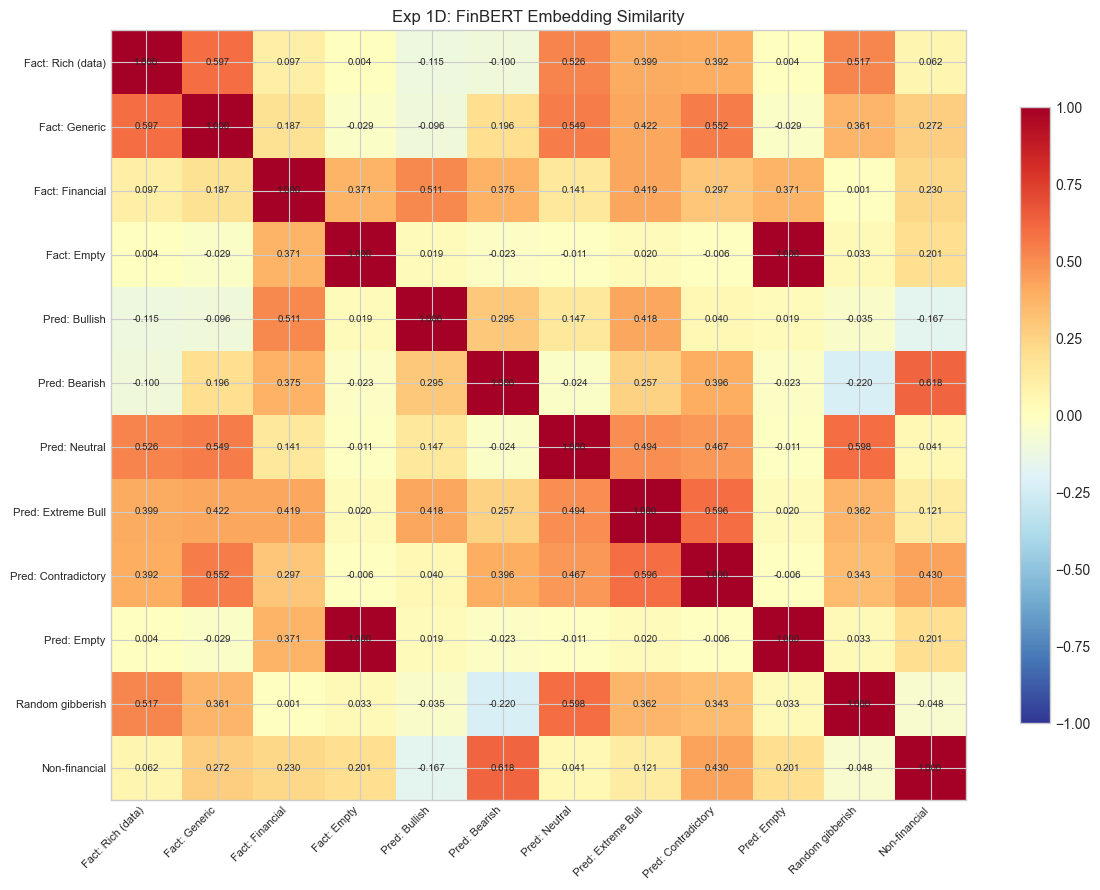

In [14]:
# Build cosine similarity matrix
emb_dict = {name: raw_embeddings[i] for i, name in enumerate(all_names)}
sim_matrix = cosine_sim_matrix(emb_dict)

fig, ax = plot_similarity_matrix(sim_matrix, title="Exp 1D: FinBERT Embedding Similarity", figsize=(12, 9))
plt.show()

In [15]:
# Key pairwise comparisons
pairs = [
    ("Pred: Bullish", "Pred: Bearish", "Bull vs Bear (opposite sentiment)"),
    ("Pred: Bullish", "Pred: Neutral", "Bull vs Neutral"),
    ("Pred: Bullish", "Pred: Extreme Bull", "Bull vs Extreme Bull (same direction)"),
    ("Pred: Bullish", "Pred: Contradictory", "Bull vs Contradictory"),
    ("Fact: Rich (data)", "Fact: Generic", "Rich factual vs Generic factual"),
    ("Fact: Rich (data)", "Fact: Financial", "Cement factual vs Finance factual"),
    ("Fact: Rich (data)", "Pred: Bullish", "Factual section vs Predictive section"),
    ("Pred: Empty", "Fact: Empty", "Empty vs Empty"),
    ("Pred: Bullish", "Random gibberish", "Bullish vs Random"),
    ("Pred: Bullish", "Non-financial", "Bullish vs Non-financial"),
]

print(f"{'Comparison':<45} {'Cosine Sim':>11}")
print("-" * 58)
for name_a, name_b, desc in pairs:
    sim = cosine_sim(emb_dict[name_a], emb_dict[name_b])
    print(f"{desc:<45} {sim:>11.4f}")

Comparison                                     Cosine Sim
----------------------------------------------------------
Bull vs Bear (opposite sentiment)                  0.2951
Bull vs Neutral                                    0.1467
Bull vs Extreme Bull (same direction)              0.4182
Bull vs Contradictory                              0.0403
Rich factual vs Generic factual                    0.5970
Cement factual vs Finance factual                  0.0973
Factual section vs Predictive section             -0.1152
Empty vs Empty                                     1.0000
Bullish vs Random                                 -0.0349
Bullish vs Non-financial                          -0.1669


/opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value enc

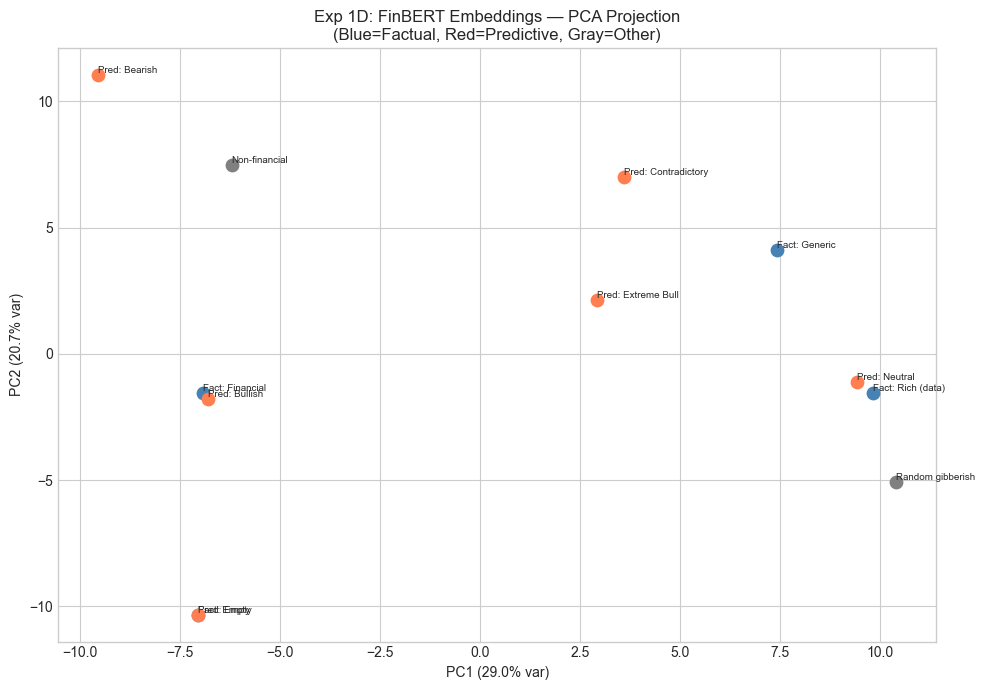

(0 zero-norm embeddings excluded from PCA)


In [16]:
# PCA projection of all embeddings to 2D (exclude zero-norm embeddings like empty strings)
from sklearn.decomposition import PCA

norms = np.linalg.norm(raw_embeddings, axis=1)
valid_mask = norms > 1e-6
valid_names = [n for n, v in zip(all_names, valid_mask) if v]
valid_embs = raw_embeddings[valid_mask]

pca = PCA(n_components=2)
coords = pca.fit_transform(valid_embs)

fig, ax = plt.subplots(figsize=(10, 7))

for i, name in enumerate(valid_names):
    if name.startswith("Fact:"):
        c = "steelblue"
    elif name.startswith("Pred:"):
        c = "coral"
    else:
        c = "gray"
    ax.scatter(coords[i, 0], coords[i, 1], c=c, s=80, zorder=3)
    ax.annotate(name, (coords[i, 0], coords[i, 1]), fontsize=7, ha="left", va="bottom")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("Exp 1D: FinBERT Embeddings — PCA Projection\n(Blue=Factual, Red=Predictive, Gray=Other)")
plt.tight_layout()
plt.show()
print(f"({sum(~valid_mask)} zero-norm embeddings excluded from PCA)")

## Experiment 1E — Ablation: Zero, Random, and Swapped Embeddings

To understand the **maximum possible text effect**, we bypass the normal text pipeline and directly inject controlled embeddings into the model's forward pass. This requires hooking deeper into the model.

We test:
1. **Normal** — standard FinBERT embeddings from a bullish summary
2. **Zero text** — both factual and predictive embeddings set to zero
3. **Random text** — Gaussian random embeddings (same scale as real ones)
4. **Swapped** — factual and predictive embeddings exchanged
5. **Amplified** — normal embeddings scaled by 5x (test if magnitude matters)

In [17]:
# For ablation, we need to directly manipulate embeddings.
# We'll use hooks on fact_embedder and prediction_embedder to override their output.

class AblationRunner:
    """Run forward passes with manipulated text embeddings."""

    def __init__(self, pipeline, extractor):
        self.pipeline = pipeline
        self.model = pipeline.model
        self.extractor = extractor

    def _run_with_overrides(self, context_values, summary, pred_len,
                            fact_override=None, pred_override=None):
        """Run extraction but override factual/predictive embeddings after projection."""
        hooks = []
        if fact_override is not None:
            def hook_fact(module, input, output):
                return fact_override.to(output.device)
            hooks.append(self.model.fact_embedder.register_forward_hook(hook_fact))

        if pred_override is not None:
            def hook_pred(module, input, output):
                return pred_override.to(output.device)
            hooks.append(self.model.prediction_embedder.register_forward_hook(hook_pred))

        try:
            results = self.extractor.run(context_values, summary, pred_len)
        finally:
            for h in hooks:
                h.remove()
        return results

    def run_ablations(self, context_values, summary, pred_len=8):
        """Run all ablation conditions and return results dict."""
        # First, get normal embeddings to use as reference
        normal = self.extractor.run(context_values, summary, pred_len)
        fact_emb = torch.tensor(normal["fact_embedding_normed"]).unsqueeze(0).float()
        pred_emb = torch.tensor(normal["pred_embedding_normed"]).unsqueeze(0).float()

        results = {"Normal": normal}

        # Zero embeddings
        zero_fact = torch.zeros_like(fact_emb)
        zero_pred = torch.zeros_like(pred_emb)
        results["Zero Text"] = self._run_with_overrides(
            context_values, summary, pred_len,
            fact_override=zero_fact, pred_override=zero_pred
        )

        # Random embeddings (same scale)
        scale = fact_emb.norm().item()
        rand_fact = torch.randn_like(fact_emb) * scale / (512 ** 0.5)
        rand_pred = torch.randn_like(pred_emb) * scale / (512 ** 0.5)
        results["Random Text"] = self._run_with_overrides(
            context_values, summary, pred_len,
            fact_override=rand_fact, pred_override=rand_pred
        )

        # Swapped: factual ↔ predictive
        results["Swapped (F↔P)"] = self._run_with_overrides(
            context_values, summary, pred_len,
            fact_override=pred_emb, pred_override=fact_emb
        )

        # Amplified: 5x normal embeddings
        results["Amplified (5x)"] = self._run_with_overrides(
            context_values, summary, pred_len,
            fact_override=fact_emb * 5, pred_override=pred_emb * 5
        )

        return results

ablation = AblationRunner(pipeline, extractor)
ablation_results = ablation.run_ablations(
    context_values, scenarios_1a["Rich+Bullish"], pred_len=PRED_LEN
)

print("Ablation runs completed:", list(ablation_results.keys()))

Ablation runs completed: ['Normal', 'Zero Text', 'Random Text', 'Swapped (F↔P)', 'Amplified (5x)']


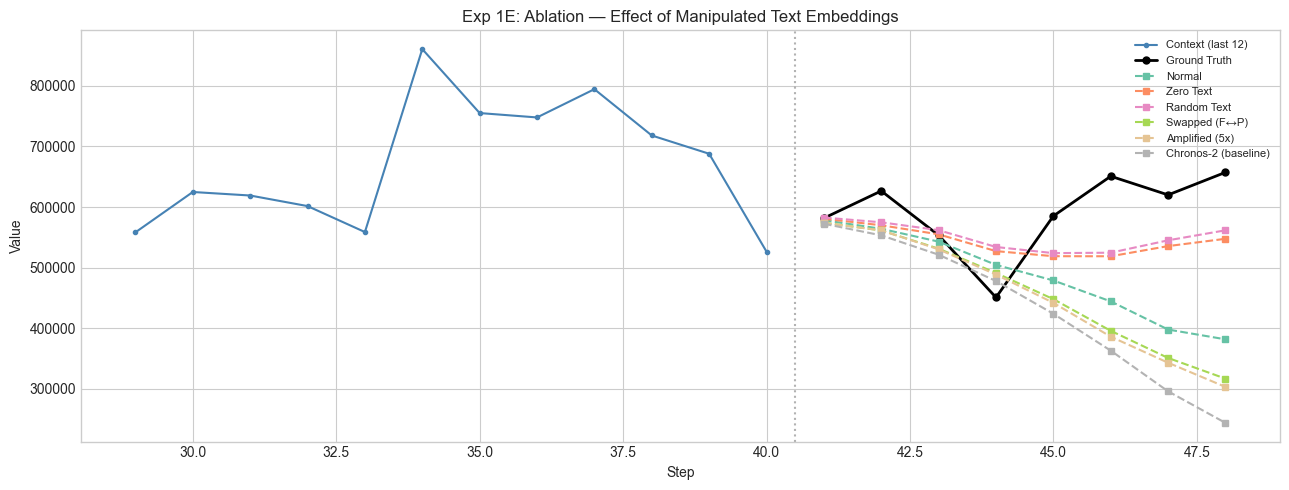

Condition                 MAE vs GT    TextShift  MAE vs Normal
--------------------------------------------------------------
Normal                      117,579       55,123              0
Zero Text                    66,017      112,749         57,626
Random Text                  62,805      119,633         64,510
Swapped (F↔P)               142,111       27,253         27,869
Amplified (5x)              146,617       22,086         33,036
Chronos-2 (baseline)        166,046            0         55,123


In [18]:
# Compare forecasts across ablation conditions
abl_forecasts = {name: r["forecast"] for name, r in ablation_results.items()}
abl_forecasts["Chronos-2 (baseline)"] = ablation_results["Normal"]["chronos_forecast"]

fig, ax = plot_forecast_comparison(
    context_values, abl_forecasts, ground_truth=gt,
    title="Exp 1E: Ablation — Effect of Manipulated Text Embeddings"
)
plt.show()

# Metrics
print(f"{'Condition':<22} {'MAE vs GT':>12} {'TextShift':>12} {'MAE vs Normal':>14}")
print("-" * 62)
normal_fc = abl_forecasts["Normal"]
chronos_fc = abl_forecasts["Chronos-2 (baseline)"]
for name, fc in abl_forecasts.items():
    mae_gt = np.mean(np.abs(gt - fc))
    shift = text_shift(fc, chronos_fc) if name != "Chronos-2 (baseline)" else 0
    mae_normal = np.mean(np.abs(fc - normal_fc)) if name != "Normal" else 0
    print(f"{name:<22} {mae_gt:>12,.0f} {shift:>12,.0f} {mae_normal:>14,.0f}")

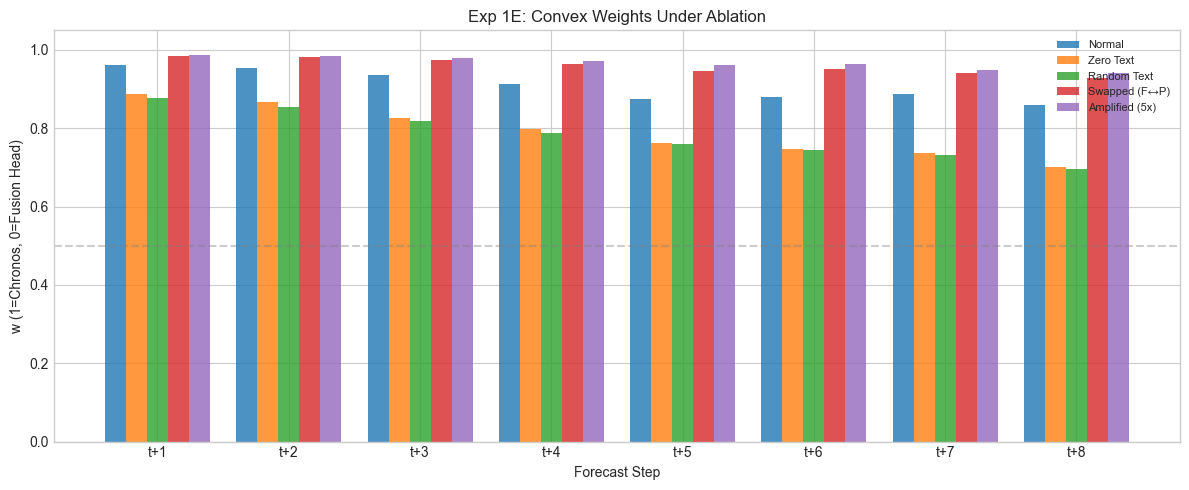

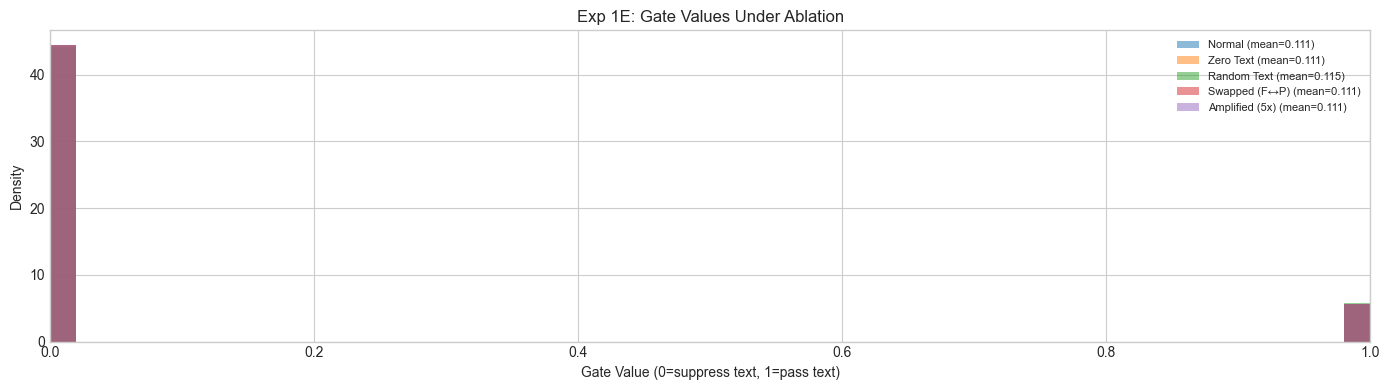

In [19]:
# Compare convex weights under ablation conditions
abl_weights = {name: r["convex_weights"] for name, r in ablation_results.items()
               if "convex_weights" in r}

fig, ax = plot_convex_weights(abl_weights, title="Exp 1E: Convex Weights Under Ablation")
plt.show()

# Gate comparison
abl_gates = {name: r["gate_values"] for name, r in ablation_results.items()
             if "gate_values" in r}

fig, ax = plot_gate_values(abl_gates, title="Exp 1E: Gate Values Under Ablation")
plt.show()

## Summary of Key Findings

<!-- Run this notebook and fill in observations below:

### Exp 1A — Factual vs. Predictive Isolation
- **Factual effect** (changing factual, same predictive): ___ MAE
- **Predictive effect** (changing predictive, same factual): ___ MAE
- **Ratio**: Factual is ___x more influential than predictive
- **Conclusion**: ___ (e.g., "The factual section dominates; this explains the original bullish≈bearish observation")

### Exp 1B — Convex Weights
- **Average w**: ___ (closer to 0 or 1?)
- **Interpretation**: The model trusts Chronos ___% and fusion head ___% on average
- **Variation across scenarios**: ___ (do weights change with text?)

### Exp 1C — Gate & Attention
- **Attention split**: Factual gets ___% vs Predictive gets ___%
- **Gate mean**: ___ (how much text signal passes through?)
- **Gate variation**: ___ (does it change with different text?)

### Exp 1D — FinBERT Similarity
- **Bull vs Bear cosine similarity**: ___ (can FinBERT distinguish them?)
- **Rich vs Generic factual similarity**: ___ (how different are they?)
- **Key insight**: ___

### Exp 1E — Ablation
- **Zero text vs Normal**: ___ difference (maximum text effect)
- **Random text vs Normal**: ___
- **Amplified vs Normal**: ___ (does magnitude matter?)
- **Key insight**: ___ -->